# Exploration — Lumina & Co (notebook personnel de Kémil)

Ce notebook est séparé de `notebook_TP1_...` et `notebook_TP2_...` pour ne pas perturber le travail des partenaires de groupe.

**Point de départ :** en observant les données, on a remarqué qu'une seule campagne — celle du printemps (`Spring_Launch`) — dépasse le million d'euros de revenu, alors que les autres non. Objectif : comprendre pourquoi, et voir ce qui est réplicable sur les autres campagnes.

**Deuxième volet :** creuser les profils clients au-delà du RFM brut, en croisant la segmentation comportementale avec les données zero-party (préférences déclarées, âge, situation de vie, densité urbaine) pour voir si ça permet d'affiner l'expérience client.


## 1. Le pic du printemps est-il un effet saisonnier récurrent ?

On recalcule le chiffre d'affaires réel par saison, année par année, à partir de `transactions_clean.csv` (donnée déjà nettoyée en TP1, avec le fix du filtre `code_atypique`).

In [ ]:
tx = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])

tx["annee"]  = tx["invoice_date"].dt.year
tx["mois"]   = tx["invoice_date"].dt.month
tx["saison"] = tx["mois"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Ete", 7: "Ete", 8: "Ete",
    9: "Automne", 10: "Automne", 11: "Automne"
})

print("====== CA par annee x saison ======")
ca_annee_saison = tx.groupby(["annee", "saison"])["line_total"].sum().unstack().round(0)
print(ca_annee_saison)

print("\n====== CA total par saison (toutes annees confondues) ======")
print(tx.groupby("saison")["line_total"].sum().sort_values(ascending=False).round(0))


====== CA par annee x saison ======
saison    Automne        Ete      Hiver  Printemps
annee                                             
2022      17669.0     5180.0    12890.0     2260.0
2023     210884.0   133472.0   120501.0    71867.0
2024    2902837.0  2007399.0  1283575.0   528058.0
2025    3144198.0  3488312.0  3110648.0  3924023.0
2026          NaN  1354019.0  2146118.0  4176421.0

====== CA total par saison (toutes annees confondues) ======
saison
Printemps    8702629.0
Ete          6988381.0
Hiver        6673733.0
Automne      6275589.0
Name: line_total, dtype: float64


**Lecture :** en 2022, 2023 et 2024, le printemps est en réalité la saison la **plus faible** de l'année (ex: 2024 → 528k€ contre 1,28M-2,9M pour les autres saisons). Ce n'est qu'en 2025 qu'il dépasse à peine l'été, et en 2026 la comparaison est biaisée car l'été et l'automne n'ont que quelques mois de données.

**Conclusion : il n'y a pas d'effet saisonnier naturel qui favorise le printemps.** Le pic de 2026 n'est pas une récurrence historique.

## 2. Ce que dit `campaigns.csv` : budget vs efficacité

Cette table (et `touchpoints.csv`) existent dans le projet mais n'avaient jamais été exploitées en TP1/TP2. Elles contiennent la performance agrégée par campagne (budget, revenu, taux de conversion, ROAS).

In [ ]:
campaigns = pd.read_csv("Lumina & Co - CRM/campaigns.csv")

campaigns["budget_relatif"] = (campaigns["total_cost"] / campaigns["total_cost"].min()).round(2)

print("====== Campagnes triees par revenu ======")
cols = ["campaign_name", "total_cost", "revenue", "conversion_rate", "roas", "cpa", "primary_channel"]
print(campaigns.sort_values("revenue", ascending=False)[cols].to_string(index=False))

print("\n====== Budget relatif (vs la campagne la moins chere) ======")
print(campaigns[["campaign_name", "total_cost", "budget_relatif"]].sort_values("total_cost", ascending=False).to_string(index=False))

print("\n====== Simulation : et si Winter_Promo avait eu le budget de Spring_Launch ? ======")
winter = campaigns[campaigns["campaign_name"] == "Winter_Promo"].iloc[0]
spring = campaigns[campaigns["campaign_name"] == "Spring_Launch"].iloc[0]
revenu_hypothetique = spring["total_cost"] * winter["roas"]
print(f"Budget Spring_Launch applique au ROAS de Winter_Promo : {revenu_hypothetique:,.0f} EUR")
print(f"Revenu reel de Spring_Launch                          : {spring['revenue']:,.0f} EUR")


====== Campagnes triees par revenu ======
 campaign_name  total_cost    revenue  conversion_rate  roas   cpa primary_channel
 Spring_Launch 374813.3262 1686555.27           0.7655  4.50 18.40         display
  Black_Friday 205749.4125  957170.87           0.6971  4.65 10.96         display
     Valentine 247465.9644  853184.79           0.5857  3.45 16.34         display
Back_to_School 159256.4075  725541.50           0.5168  4.56 12.07          social
  Winter_Promo 133949.0025  716632.64           0.5527  5.35  9.45         display
   Summer_Sale 226774.1597  621009.60           0.5010  2.74 17.84         display

====== Budget relatif (vs la campagne la moins chere) ======
 campaign_name  total_cost  budget_relatif
 Spring_Launch 374813.3262            2.80
     Valentine 247465.9644            1.85
   Summer_Sale 226774.1597            1.69
  Black_Friday 205749.4125            1.54
Back_to_School 159256.4075            1.19
  Winter_Promo 133949.0025            1.00

====== Simula

**Lecture :** `Spring_Launch` a un budget de 374 813€ — **2,8× le budget de la campagne la moins chère** (`Winter_Promo`, 133 949€). C'est le plus gros budget de toutes les campagnes.

Son ROAS (retour par euro dépensé) est de 4,50 — ce n'est même pas le meilleur : `Winter_Promo` fait 5,35 avec un budget presque 3× plus petit.

**Conclusion : le printemps ne dépasse le million pas grâce à un effet magique, mais parce qu'on lui a alloué beaucoup plus de budget — et pas forcément au canal le plus efficace.** À budget égal, `Winter_Promo` aurait généré davantage de revenu que `Spring_Launch`.

**Piste actionnable pour "réitérer" :** ne pas copier le printemps, mais réallouer une partie du budget vers les campagnes les plus efficientes (ROAS le plus élevé), et comprendre pourquoi leur mix canal/timing convertit mieux par euro dépensé — à explorer avec `touchpoints.csv` (canaux, position dans le parcours) dans une prochaine étape.

## 3. Segmentation clients par règles (au-delà des 3 cas extrêmes)

La consigne TP2 demande de dépasser les segments "555 / 111 / à risque" (qui ne couvrent que les cas extrêmes) avec des règles par plage justifiées, pour arriver à 5-8 segments nommés couvrant toute la base.

In [ ]:
customers = pd.read_csv("clean_data/customers_clean.csv")

# Scores RFM par quintiles (1 a 5)
customers["score_R"] = pd.qcut(customers["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
customers["score_F"] = pd.qcut(customers["n_orders"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
customers["score_M"] = pd.qcut(customers["total_spent"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segmenter(row):
    r, f, m = row["score_R"], row["score_F"], row["score_M"]
    if r >= 4 and f >= 4 and m >= 4:            return "Champions"
    if r >= 4 and f <= 2:                       return "Nouveaux prometteurs"
    if r <= 2 and f >= 4 and m >= 4:            return "A risque (forte valeur, inactifs)"
    if r <= 2 and f <= 2 and m <= 2:            return "Perdus"
    if r >= 3 and f >= 3 and m >= 3:            return "Fideles"
    if r <= 2:                                  return "Hibernants"
    return "Clients moyens"

customers["segment"] = customers.apply(segmenter, axis=1)

print("====== Repartition des segments ======")
rep = customers["segment"].value_counts()
print(rep)
print((rep / len(customers) * 100).round(1).astype(str) + " %")

print("\n====== Part du CA par segment ======")
ca_seg = customers.groupby("segment")["total_spent"].sum().sort_values(ascending=False)
print((ca_seg / customers["total_spent"].sum() * 100).round(1).astype(str) + " %")


====== Repartition des segments ======
segment
Champions                            10003
Perdus                                9625
Fideles                               9457
Hibernants                            8192
Clients moyens                        6228
Nouveaux prometteurs                  4089
A risque (forte valeur, inactifs)     2035
Name: count, dtype: int64
segment
Champions                            20.2 %
Perdus                               19.4 %
Fideles                              19.1 %
Hibernants                           16.5 %
Clients moyens                       12.5 %
Nouveaux prometteurs                  8.2 %
A risque (forte valeur, inactifs)     4.1 %
Name: count, dtype: str

====== Part du CA par segment ======
segment
Champions                            53.0 %
Fideles                              22.3 %
Hibernants                            9.0 %
A risque (forte valeur, inactifs)     7.0 %
Clients moyens                        3.0 %
Nouveaux prometteurs

**Règles utilisées** (documentées, à adapter/justifier dans le rendu final) :
- **Champions** : récent, fréquent, gros montant (R≥4, F≥4, M≥4)
- **Nouveaux prometteurs** : récent mais peu de commandes (R≥4, F≤2)
- **À risque** : forte valeur historique mais inactif depuis longtemps (R≤2, F≥4, M≥4)
- **Perdus** : tout est bas (R≤2, F≤2, M≤2)
- **Fidèles** : scores moyens-hauts sur les trois dimensions (R≥3, F≥3, M≥3)
- **Hibernants** : peu récent, sans forte valeur ni forte fréquence (R≤2, reste)
- **Clients moyens** : tout ce qui ne rentre dans aucune règle ci-dessus

**Lecture :** 7 segments, 100% de la base couverte. Champions = 20,2% des clients mais 53% du CA (Pareto confirmé). Perdus = 19,4% des clients pour seulement 2,8% du CA. À risque = seulement 4,1% des clients mais 7% du CA — prioritaires pour une action de réactivation ciblée.

## 4. Le comportement d'achat (RFM) est-il lié au profil déclaré (zero-party) ?

"Pour aller plus loin" du TP2 : croiser un segment RFM avec un champ zero-party pour voir si ça révèle un profil plus précis qu'avec le RFM seul.

In [ ]:
zp_cols = ["declared_preference", "age_bracket", "life_stage", "urban_density"]

print("====== Taux de remplissage zero-party PAR SEGMENT (%) ======")
taux = customers.groupby("segment")[zp_cols].apply(lambda g: g.notna().mean() * 100).round(1)
print(taux)

print("\n====== declared_preference : repartition PAR SEGMENT, parmi ceux qui ont repondu (%) ======")
sub = customers[customers["declared_preference"].notna()]
crosstab = (pd.crosstab(sub["segment"], sub["declared_preference"], normalize="index") * 100).round(1)
print(crosstab)


====== Taux de remplissage zero-party PAR SEGMENT (%) ======
                                   declared_preference  ...  urban_density
segment                                                 ...               
A risque (forte valeur, inactifs)                 37.5  ...           21.3
Champions                                         38.0  ...           20.1
Clients moyens                                    38.6  ...           19.6
Fideles                                           37.8  ...           19.7
Hibernants                                        37.5  ...           19.5
Nouveaux prometteurs                              37.9  ...           19.1
Perdus                                            39.0  ...           19.9

[7 rows x 4 columns]

====== declared_preference : repartition PAR SEGMENT, parmi ceux qui ont repondu (%) ======
declared_preference                Anti-imperfections  ...  Sans parfum
segment                                                ...             
A ris

**Lecture :** le taux de réponse aux enquêtes (37-39% pour la préférence, 42-43% pour l'âge, ~20-23% pour la situation de vie et la densité urbaine) est quasi identique quel que soit le segment — un Champion ne répond pas plus ou moins qu'un client Perdu. La répartition des préférences déclarées est également plate sur tous les segments (écarts de 1 à 3 points = bruit statistique, pas un signal).

**Conclusion : dans cette base, le comportement d'achat (RFM) et le profil déclaré (zero-party) sont statistiquement indépendants.** Croiser les deux n'affine pas la segmentation — mais le zero-party reste utile *au niveau individuel* : personnaliser le message ou le produit recommandé à un client qui a répondu à l'enquête, indépendamment de son segment de valeur.


## Synthèse

1. Le pic de revenu du printemps 2026 n'est pas un effet saisonnier récurrent (il était même historiquement la saison la plus faible) — c'est un effet de budget marketing (2,8× le budget de la campagne la moins chère), pas d'efficacité (ROAS pas le meilleur).
2. Piste d'action : réallouer du budget vers les campagnes à meilleur ROAS (`Winter_Promo`) plutôt que de chercher à "reproduire" le printemps.
3. La segmentation RFM par règles couvre 100% de la base en 7 segments actionnables, avec une forte concentration de valeur sur les Champions (53% du CA pour 20% des clients).
4. Le croisement RFM × zero-party ne révèle pas de profil démographique/préférence distinctif par segment — ces données restent utiles pour la personnalisation individuelle, pas pour la segmentation.

**Prochaine étape possible :** creuser `touchpoints.csv` (canal, position dans le parcours, coût par touchpoint) pour comprendre precisement *pourquoi* `Winter_Promo` convertit mieux par euro dépensé que les autres campagnes.


## 5. Quels profils reviennent (ou pas) selon la saison et l'année ?

On reprend la segmentation de la section 3 et on regarde, saison par saison puis année par année, quels segments dominent — et surtout, qui ne suit pas un pattern stable.

In [ ]:
# recharge et resegmente (identique a la section 3)
customers = pd.read_csv("clean_data/customers_clean.csv")
customers["score_R"] = pd.qcut(customers["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
customers["score_F"] = pd.qcut(customers["n_orders"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
customers["score_M"] = pd.qcut(customers["total_spent"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segmenter(row):
    r, f, m = row["score_R"], row["score_F"], row["score_M"]
    if r >= 4 and f >= 4 and m >= 4:            return "Champions"
    if r >= 4 and f <= 2:                       return "Nouveaux prometteurs"
    if r <= 2 and f >= 4 and m >= 4:            return "A risque"
    if r <= 2 and f <= 2 and m <= 2:            return "Perdus"
    if r >= 3 and f >= 3 and m >= 3:            return "Fideles"
    if r <= 2:                                  return "Hibernants"
    return "Clients moyens"

customers["segment"] = customers.apply(segmenter, axis=1)

tx = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])
tx["annee"]  = tx["invoice_date"].dt.year
tx["mois"]   = tx["invoice_date"].dt.month
tx["saison"] = tx["mois"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Ete", 7: "Ete", 8: "Ete",
    9: "Automne", 10: "Automne", 11: "Automne"
})
tx = tx.merge(customers[["customer_id", "segment"]], on="customer_id", how="left")
print("Segmentation et jointure OK —", tx["segment"].isna().sum(), "lignes sans segment")


Segmentation et jointure OK — 9 lignes sans segment


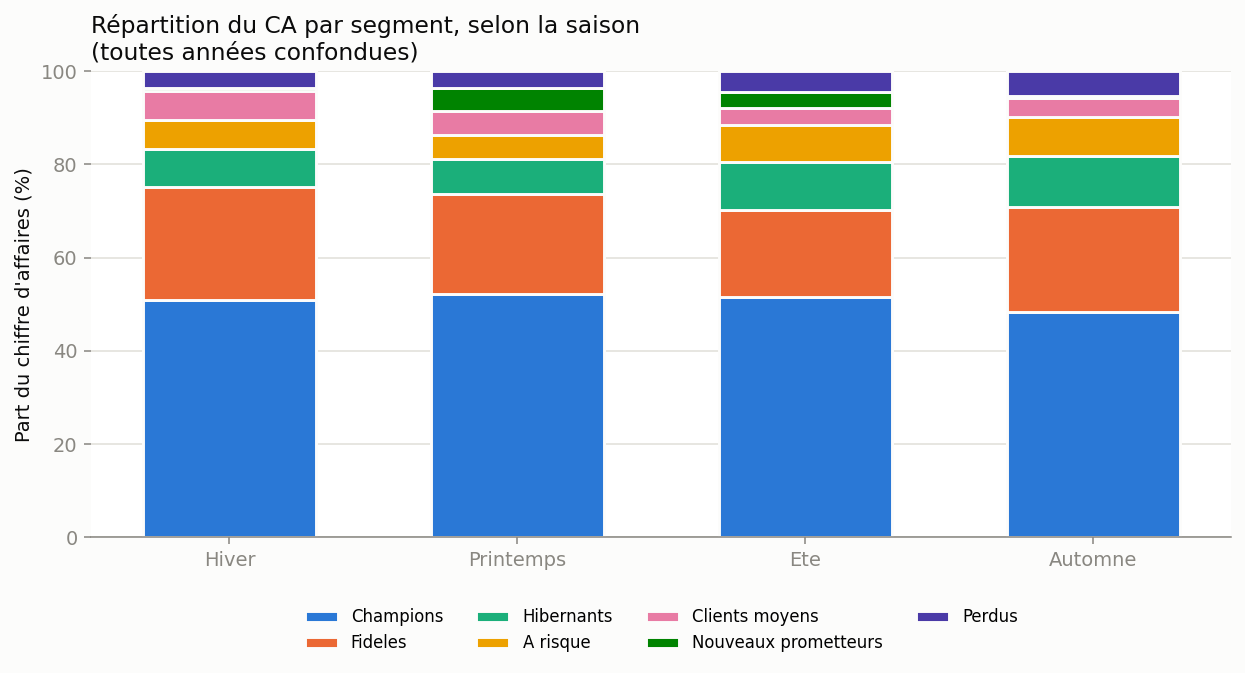

In [ ]:
saisons_ordre = ["Hiver", "Printemps", "Ete", "Automne"]
segs_ordre = ["Champions", "Fideles", "Hibernants", "A risque", "Clients moyens", "Nouveaux prometteurs", "Perdus"]
PAL = {
    "Champions": "#2a78d6", "Fideles": "#eb6834", "Hibernants": "#1baf7a",
    "A risque": "#eda100", "Clients moyens": "#e87ba4",
    "Nouveaux prometteurs": "#008300", "Perdus": "#4a3aa7",
}

ca_seg_saison = tx.groupby(["saison", "segment"])["line_total"].sum().unstack(fill_value=0)
ca_seg_saison = ca_seg_saison.reindex(index=saisons_ordre, columns=segs_ordre)
ca_pct = ca_seg_saison.div(ca_seg_saison.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
bottom = pd.Series(0.0, index=ca_pct.index)
for seg in segs_ordre:
    vals = ca_pct[seg]
    ax.bar(ca_pct.index, vals, bottom=bottom, width=0.6, color=PAL[seg], label=seg,
           edgecolor="white", linewidth=1.5)
    bottom += vals
ax.set_ylabel("Part du chiffre d'affaires (%)")
ax.set_title("Répartition du CA par segment, selon la saison\n(toutes années confondues)", loc="left")
ax.set_ylim(0, 100)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()


**Lecture :** Champions (bleu) et Fidèles (orange) dominent le CA sur **toutes** les saisons dans des proportions quasi identiques (~48-52% et ~19-24%) — ce sont des segments stables, pas saisonniers. Le seul segment dont la barre change nettement de taille selon la saison, c'est Nouveaux prometteurs (vert) — quasi invisible en Hiver/Automne, nettement plus large en Printemps.

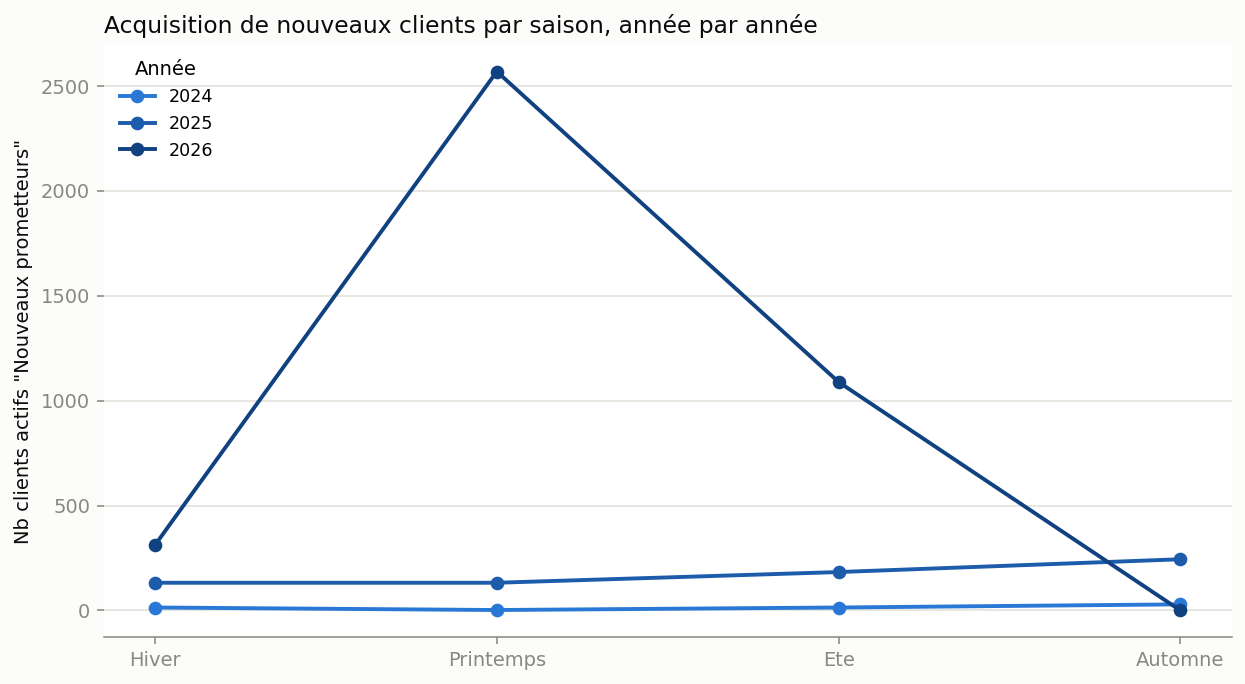

In [ ]:
np_clients = tx[tx["segment"] == "Nouveaux prometteurs"].groupby(["annee", "saison"])["customer_id"].nunique().unstack(fill_value=0)
np_clients = np_clients.reindex(columns=saisons_ordre)

annee_colors = {2022: "#86b6ef", 2023: "#5598e7", 2024: "#2a78d6", 2025: "#1c5cab", 2026: "#104281"}

fig, ax = plt.subplots(figsize=(9, 5))
for annee in sorted(np_clients.index):
    if annee not in annee_colors:
        continue
    ax.plot(saisons_ordre, np_clients.loc[annee, saisons_ordre], marker="o", markersize=6,
            linewidth=2, color=annee_colors[annee], label=str(annee))
ax.set_ylabel('Nb clients actifs "Nouveaux prometteurs"')
ax.set_title("Acquisition de nouveaux clients par saison, année par année", loc="left")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper left", frameon=False, fontsize=9, title="Année")
plt.tight_layout()
plt.show()


**Lecture :** de 2022 à 2025, les courbes sont plates et proches de zéro, quelle que soit la saison — aucun pattern saisonnier d'acquisition. En 2026 (bleu le plus sombre), la courbe décolle uniquement au printemps (2 569 nouveaux clients actifs, contre 312 en hiver la même année) : ça correspond exactement à la fenêtre de la campagne `Spring_Launch`.

**Conclusion de la section :** les segments de valeur (Champions, Fidèles, Perdus, À risque) sont stables dans le temps — ce ne sont pas des profils "saisonniers". Le seul segment qui varie fortement selon la saison, et qui n'est pas récurrent d'année en année, c'est Nouveaux prometteurs — et ça suit une seule campagne d'acquisition en particulier, pas un rythme naturel. Ça renforce la conclusion de la section 2 : le succès du printemps 2026 est piloté par une action marketing ponctuelle (acquisition), pas par un comportement qui "revient" chaque année.

## 6. La vraie acquisition de nouveaux clients (`first_purchase`), pas le proxy RFM

Le segment "Nouveaux prometteurs" de la section 5 est un proxy RFM (récent + peu de commandes) — on a vérifié qu'il colle à un vrai nouveau client dans 80% des cas seulement. Ici on regarde directement la date de première commande (`first_purchase` dans `customers_clean.csv`) pour savoir, sans ambiguïté, quand les clients sont réellement acquis.

In [ ]:
customers = pd.read_csv("clean_data/customers_clean.csv", parse_dates=["first_purchase"])
customers["annee"] = customers["first_purchase"].dt.year
customers["mois"]  = customers["first_purchase"].dt.month
customers["saison"] = customers["mois"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Ete", 7: "Ete", 8: "Ete",
    9: "Automne", 10: "Automne", 11: "Automne"
})

print("====== Nb de VRAIS nouveaux clients (1ere commande) par annee ======")
print(customers["annee"].value_counts().sort_index())

print("\n====== Repartition par annee x saison ======")
acquisition = customers.groupby(["annee", "saison"]).size().unstack(fill_value=0)
acquisition = acquisition.reindex(columns=["Hiver", "Printemps", "Ete", "Automne"])
print(acquisition)

print("\n====== Part de chaque saison dans l acquisition de l annee (%) ======")
print((acquisition.div(acquisition.sum(axis=1), axis=0) * 100).round(1))

print("\nNote : 11 clients ont un first_purchase en 2021, avant le debut de transactions.csv (07/01/2022).")
print("Probable incoherence mineure d export CRM -> exclus du graphique ci-dessous, negligeable sur le total.")


====== Nb de VRAIS nouveaux clients (1ere commande) par annee ======
annee
2021       11
2022     2339
2023     8082
2024    20933
2025    11772
2026     6492
Name: count, dtype: int64

====== Repartition par annee x saison ======
saison  Hiver  Printemps   Ete  Automne
annee                                  
2021       11          0     0        0
2022      489        246   609      995
2023     1798       1775  2177     2332
2024     3709       5275  6792     5157
2025     3111       3820  2616     2225
2026     1909       3904   679        0

====== Part de chaque saison dans l acquisition de l annee (%) ======
saison  Hiver  Printemps   Ete  Automne
annee                                  
2021    100.0        0.0   0.0      0.0
2022     20.9       10.5  26.0     42.5
2023     22.2       22.0  26.9     28.9
2024     17.7       25.2  32.4     24.6
2025     26.4       32.4  22.2     18.9
2026     29.4       60.1  10.5      0.0

Note : 11 clients ont un first_purchase en 2021, avant le

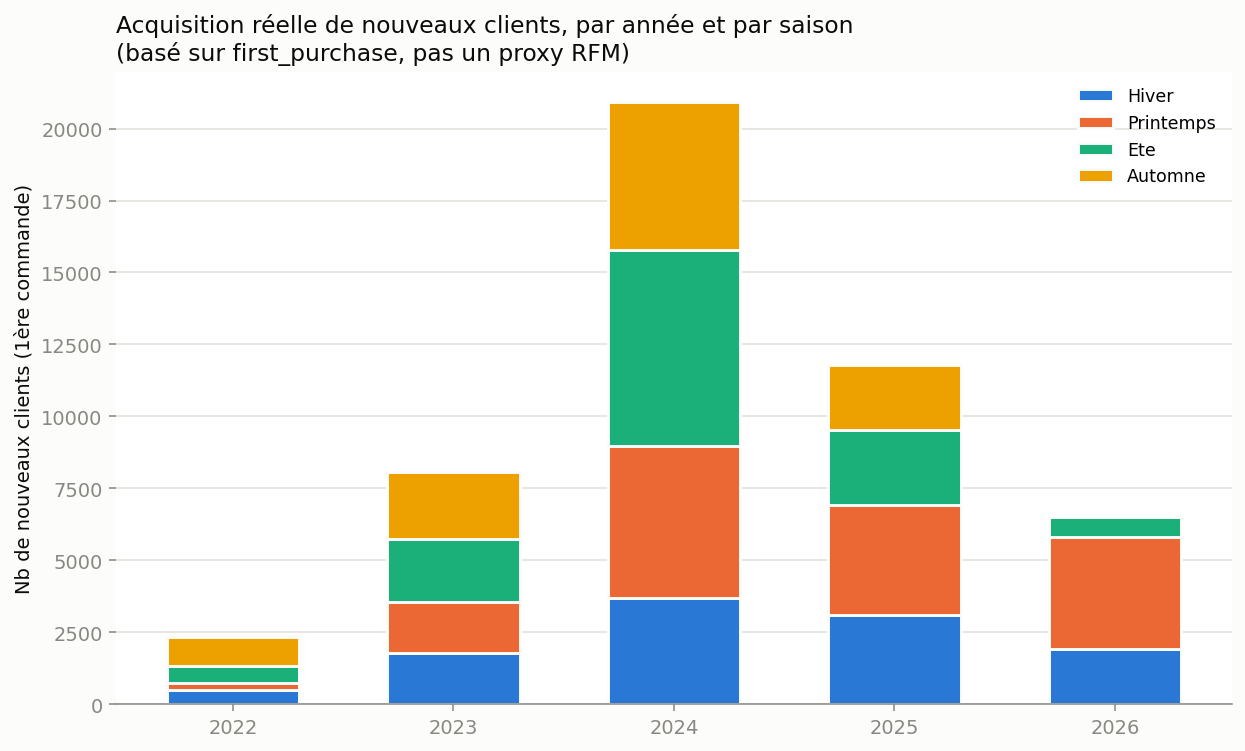

In [ ]:
acquisition = customers[customers["annee"] >= 2022].groupby(["annee", "saison"]).size().unstack(fill_value=0)
acquisition = acquisition.reindex(columns=["Hiver", "Printemps", "Ete", "Automne"])
SEASON_PAL = {"Hiver": "#2a78d6", "Printemps": "#eb6834", "Ete": "#1baf7a", "Automne": "#eda100"}

fig, ax = plt.subplots(figsize=(9, 5.5))
bottom = pd.Series(0, index=acquisition.index)
for saison in ["Hiver", "Printemps", "Ete", "Automne"]:
    vals = acquisition[saison]
    ax.bar(acquisition.index.astype(str), vals, bottom=bottom, width=0.6, color=SEASON_PAL[saison],
           label=saison, edgecolor="white", linewidth=1.5)
    bottom += vals
ax.set_ylabel("Nb de nouveaux clients (1ère commande)")
ax.set_title("Acquisition réelle de nouveaux clients, par année et par saison\n(basé sur first_purchase, pas un proxy RFM)", loc="left")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


**Lecture :** l'acquisition totale (hauteur des barres) a **culminé en 2024** (20 933 nouveaux clients) puis baisse depuis — 2025 en fait environ moitié moins, et 2026 (partiel, jusqu'en juin) est plus bas encore en volume total.

Ce qui change, c'est la composition : en 2024 l'acquisition était étalée sur les 4 saisons (17 à 32% chacune). En 2025, le printemps devient la saison la plus forte (32,4%). En **2026, le printemps concentre 60,1% de toute l'acquisition de l'année** — une concentration jamais vue avant.

**Conclusion, et ça nuance encore le message au CMO :** l'entreprise n'acquiert pas plus de nouveaux clients grâce au printemps — elle en acquiert globalement moins depuis 2024, et ce qui reste se concentre de plus en plus sur une seule fenêtre saisonnière au lieu d'être étalé sur l'année. C'est un signal d'alerte sur l'acquisition hors-saison, pas juste une bonne nouvelle sur le printemps.

## 7. Quels segments chaque campagne convertit vraiment

`touchpoints.csv` (jamais exploité jusqu'ici) donne, pour chaque client touché par chaque campagne, s'il a converti et combien ça a coûté. On croise ça avec les segments RFM pour voir qui chaque campagne convertit réellement — pas juste combien elle dépense.

In [ ]:
customers = pd.read_csv("clean_data/customers_clean.csv")
customers["score_R"] = pd.qcut(customers["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
customers["score_F"] = pd.qcut(customers["n_orders"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
customers["score_M"] = pd.qcut(customers["total_spent"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segmenter(row):
    r, f, m = row["score_R"], row["score_F"], row["score_M"]
    if r >= 4 and f >= 4 and m >= 4:            return "Champions"
    if r >= 4 and f <= 2:                       return "Nouveaux prometteurs"
    if r <= 2 and f >= 4 and m >= 4:            return "A risque"
    if r <= 2 and f <= 2 and m <= 2:            return "Perdus"
    if r >= 3 and f >= 3 and m >= 3:            return "Fideles"
    if r <= 2:                                  return "Hibernants"
    return "Clients moyens"

customers["segment"] = customers.apply(segmenter, axis=1)

touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")
touchpoints = touchpoints.merge(customers[["customer_id", "segment"]], on="customer_id", how="left")
touchpoints = touchpoints.dropna(subset=["segment"])

# par client x campagne : a-t-il converti (sur au moins un touchpoint), et cout total engage
par_client_camp = touchpoints.groupby(["campaign_name", "customer_id", "segment"]).agg(
    converti=("converted", "max"),
    cout=("cost", "sum")
).reset_index()

print("====== Nb clients touches, par segment x campagne ======")
print(par_client_camp.groupby(["campaign_name", "segment"]).size().unstack())

print("\n====== Taux de conversion par segment x campagne (%) ======")
conversion = par_client_camp.groupby(["campaign_name", "segment"])["converti"].mean().unstack() * 100
print(conversion.round(1))

print("\n====== Cout par conversion, par segment x campagne (EUR) ======")
cout_total = par_client_camp.groupby(["campaign_name", "segment"])["cout"].sum().unstack()
nb_convertis = par_client_camp.groupby(["campaign_name", "segment"])["converti"].sum().unstack()
print((cout_total / nb_convertis).round(2))


====== Nb clients touches, par segment x campagne ======
segment         A risque  Champions  ...  Nouveaux prometteurs  Perdus
campaign_name                        ...                              
Back_to_School       914       7034  ...                  1742    3281
Black_Friday         821       7753  ...                  1864    3243
Spring_Launch        753       7657  ...                  3183    3057
Summer_Sale         1029       6958  ...                  1838    3311
Valentine            727       7493  ...                  2133    3063
Winter_Promo         742       7351  ...                  1865    3160

[6 rows x 7 columns]

====== Taux de conversion par segment x campagne (%) ======
segment         A risque  Champions  ...  Nouveaux prometteurs  Perdus
campaign_name                        ...                              
Back_to_School      29.3       65.2  ...                   6.1     9.7
Black_Friday        14.5       76.4  ...                  10.6     4.4
Spring_L

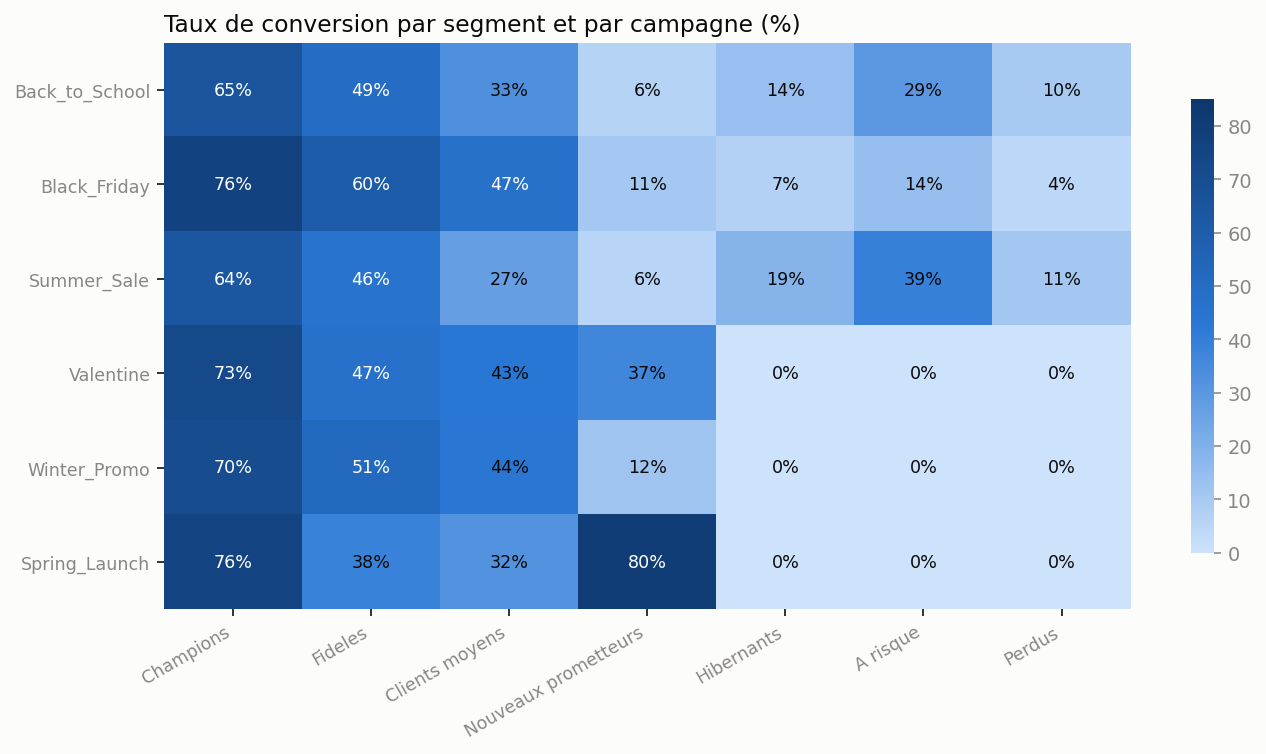

In [ ]:
segs_ordre = ["Champions", "Fideles", "Clients moyens", "Nouveaux prometteurs", "Hibernants", "A risque", "Perdus"]
camps_ordre = ["Back_to_School", "Black_Friday", "Summer_Sale", "Valentine", "Winter_Promo", "Spring_Launch"]
conversion = par_client_camp.groupby(["campaign_name", "segment"])["converti"].mean().unstack() * 100
conversion = conversion.reindex(index=camps_ordre, columns=segs_ordre)

from matplotlib.colors import LinearSegmentedColormap
seq_blue = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#2a78d6", "#0d366b"])

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(conversion.values, cmap=seq_blue, vmin=0, vmax=85, aspect="auto")
ax.set_xticks(range(len(segs_ordre)))
ax.set_xticklabels(segs_ordre, rotation=30, ha="right")
ax.set_yticks(range(len(camps_ordre)))
ax.set_yticklabels(camps_ordre)
for i in range(len(camps_ordre)):
    for j in range(len(segs_ordre)):
        val = conversion.values[i, j]
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                color="white" if val > 45 else "black", fontsize=9)
ax.set_title("Taux de conversion par segment et par campagne (%)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()


**Lecture :**

1. **La case la plus sombre du tableau, c'est `Spring_Launch` × Nouveaux prometteurs : 80%.** C'est le meilleur taux de conversion de toute la matrice, tous segments et campagnes confondus — y compris devant les Champions (65-76% selon la campagne). Le coût par conversion sur cette case (14€) est même inférieur à celui des Champions sur la même campagne (25€). **C'est ça le vrai moteur du printemps : pas le budget, mais une conversion exceptionnelle des prospects tièdes.**

2. **Trois colonnes entières à 0% :** À risque, Hibernants et Perdus affichent 0,0% de conversion sur `Spring_Launch`, `Valentine` et `Winter_Promo` — sur 700 à 3 200 clients touchés à chaque fois, donc pas un hasard d'échantillon. À l'inverse, `Back_to_School`, `Black_Friday` et `Summer_Sale` (toutes les 3 en 2025) parviennent à convertir une part réelle de ces mêmes segments (jusqu'à 39% pour À risque).

Cette coupure suit exactement la bascule 2025 → 2026, pas le canal principal (`primary_channel` ne sépare pas proprement les deux groupes de campagnes). Deux hypothèses à vérifier avec l'équipe marketing : un changement volontaire de ciblage début 2026 (exclusion des segments dormants des audiences publicitaires), ou un changement non intentionnel dans la configuration des campagnes. Dans les deux cas, c'est une vraie question à poser — pas une conclusion à trancher depuis les seules données.

**Recommandation concrète pour le CMO :** étudier précisément ce que `Spring_Launch` fait différemment pour convertir les Nouveaux prometteurs à 80% (message, offre, canal, timing) et tester la réplication de cette approche sur les prochaines campagnes visant ce même segment — plutôt que d'augmenter le budget d'une campagne "qui marche" sans savoir pourquoi. Et vérifier si l'abandon du ciblage des segments dormants depuis 2026 est un choix voulu.

## 8. Effet de la pub sur le panier moyen

On croise `touchpoints.csv` (commandes rattachées à une pub) et `transactions_clean.csv` pour voir si une commande influencée par une campagne a un panier différent d'une commande organique — et si oui, si c'est pareil pour toutes les campagnes.

In [ ]:
customers = pd.read_csv("clean_data/customers_clean.csv")
customers["score_R"] = pd.qcut(customers["recency_days"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
customers["score_F"] = pd.qcut(customers["n_orders"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
customers["score_M"] = pd.qcut(customers["total_spent"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segmenter(row):
    r, f, m = row["score_R"], row["score_F"], row["score_M"]
    if r >= 4 and f >= 4 and m >= 4:            return "Champions"
    if r >= 4 and f <= 2:                       return "Nouveaux prometteurs"
    if r <= 2 and f >= 4 and m >= 4:            return "A risque"
    if r <= 2 and f <= 2 and m <= 2:            return "Perdus"
    if r >= 3 and f >= 3 and m >= 3:            return "Fideles"
    if r <= 2:                                  return "Hibernants"
    return "Clients moyens"

customers["segment"] = customers.apply(segmenter, axis=1)

touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")
transactions = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])

panier = transactions.groupby(["invoice_id", "customer_id"])["line_total"].sum().reset_index()
panier.columns = ["invoice_id", "customer_id", "montant_panier"]
panier = panier.merge(customers[["customer_id", "segment"]], on="customer_id", how="left")

# une commande = au plus une campagne associee (verifie : aucun invoice_id n a 2 campagnes)
tp_conv = touchpoints.dropna(subset=["invoice_id"])
invoice_campaign = tp_conv.groupby("invoice_id")["campaign_name"].first().reset_index()
panier["invoice_id_f"] = panier["invoice_id"].astype(float)
panier = panier.merge(invoice_campaign, left_on="invoice_id_f", right_on="invoice_id", how="left", suffixes=("", "_tp"))
panier["touche_par_pub"] = panier["campaign_name"].notna()

print("====== Panier moyen : organique vs touche par une pub ======")
print(panier.groupby("touche_par_pub")["montant_panier"].agg(["count", "mean", "median"]).round(2))

print("\n====== Panier moyen par campagne ======")
print(panier.groupby("campaign_name")["montant_panier"].agg(["count", "mean", "median"]).round(2))

# Simpson : la pub touche plus de Champions (segment a gros panier) -> ca devrait faire monter le panier pub, pas le baisser
organic_seg_mean = panier[~panier["touche_par_pub"]].groupby("segment")["montant_panier"].mean()
pub_seg_weights = panier[panier["touche_par_pub"]]["segment"].value_counts(normalize=True)
attendu = (organic_seg_mean * pub_seg_weights).sum()
panier_pub_reel = panier[panier["touche_par_pub"]]["montant_panier"].mean()
print(f"\nPanier pub attendu si la pub touchait ces segments sans rien changer a leur comportement : {attendu:.2f} EUR")
print(f"Panier pub reellement observe : {panier_pub_reel:.2f} EUR")
print("--> ecart negatif malgre un mix de segment plus favorable : effet reel, pas un artefact de mix")

print("\n====== Chez les Champions uniquement : panier organique (164 EUR) vs panier par campagne ======")
champions = panier[panier["segment"] == "Champions"]
print(champions.groupby("campaign_name")["montant_panier"].agg(["count", "mean"]).round(2))


====== Panier moyen : organique vs touche par une pub ======
                 count    mean  median
touche_par_pub                        
False           115956  142.21   72.76
True             90530  134.22   71.88

====== Panier moyen par campagne ======
                count    mean  median
campaign_name                        
Back_to_School  12756  123.31   71.48
Black_Friday    18080  127.43   71.15
Spring_Launch   19115  169.59   77.57
Summer_Sale     12281  115.49   68.36
Valentine       14614  130.09   70.38
Winter_Promo    13684  125.16   71.13

Panier pub attendu si la pub touchait ces segments sans rien changer a leur comportement : 146.94 EUR
Panier pub reellement observe : 134.22 EUR
--> ecart negatif malgre un mix de segment plus favorable : effet reel, pas un artefact de mix

====== Chez les Champions uniquement : panier organique (164 EUR) vs panier par campagne ======
                count    mean
campaign_name                
Back_to_School   6696  128.03
Black_Frid

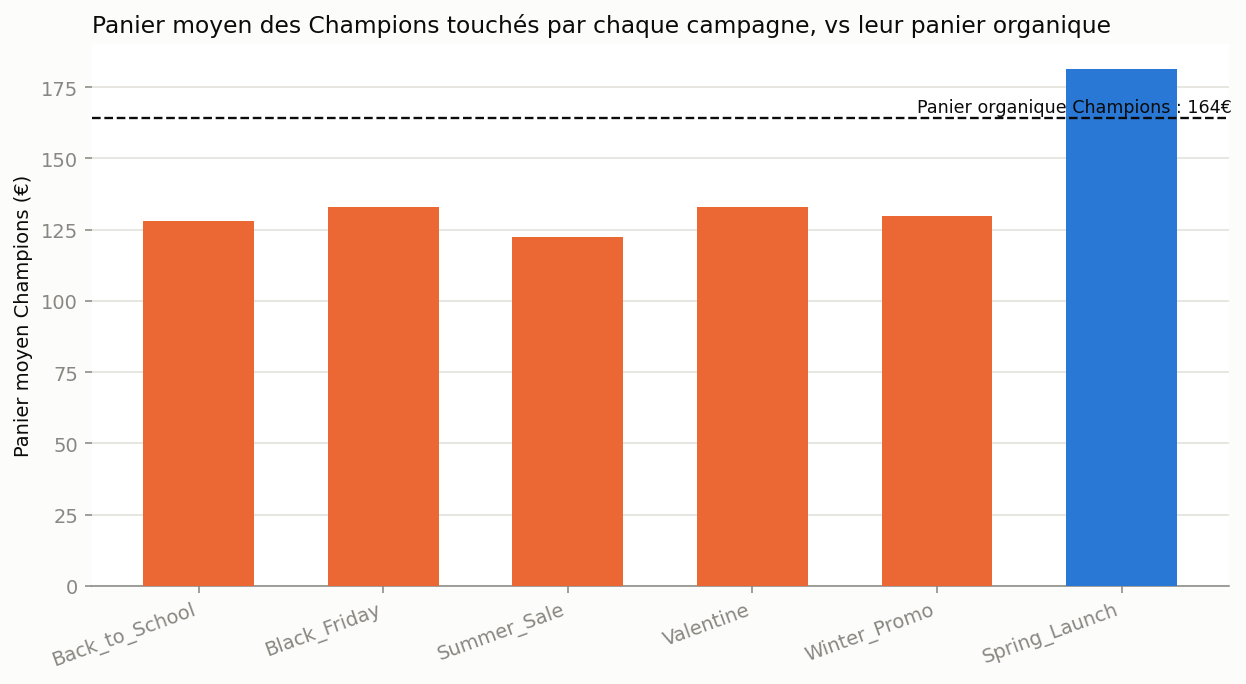

In [ ]:
ordre = ["Back_to_School", "Black_Friday", "Summer_Sale", "Valentine", "Winter_Promo", "Spring_Launch"]
organique_val = champions[~champions["touche_par_pub"]]["montant_panier"].mean()
par_camp = champions[champions["touche_par_pub"]].groupby("campaign_name")["montant_panier"].mean().reindex(ordre)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#eb6834" if c != "Spring_Launch" else "#2a78d6" for c in ordre]
ax.bar(ordre, par_camp.values, color=colors, width=0.6, zorder=3)
ax.axhline(organique_val, color="black", linewidth=1.2, linestyle="--", zorder=4)
ax.text(len(ordre) - 0.4, organique_val + 2, f"Panier organique Champions : {organique_val:.0f}€", ha="right")
ax.set_ylabel("Panier moyen Champions (€)")
ax.set_title("Panier moyen des Champions touchés par chaque campagne, vs leur panier organique", loc="left")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.show()


**Lecture rapide :**

- Vu globalement, une commande touchée par une pub a un panier légèrement plus bas que l'organique (134€ vs 142€) — mais c'est trompeur : la pub touche plus de Champions (56% vs 39% en organique), un segment à gros panier. En neutralisant ce mix, le panier pub "attendu" serait plutôt ~147€. Le panier réel (134€) est donc en dessous de cet attendu : il y a un vrai effet négatif, pas un artefact.
- Cet effet n'est pas uniforme. Chez les Champions : 5 campagnes sur 6 (Back_to_School, Black_Friday, Summer_Sale, Valentine, Winter_Promo) tirent leur panier vers le bas (-19% à -25% vs organique). **Spring_Launch fait l'inverse : +10%.**

**Hypothèse pour le CMO :** je suppose que la plupart des campagnes actuelles fonctionnent comme des déclencheurs de petits achats ponctuels (probablement portées par des remises qui réduisent le panier même chez les meilleurs clients), ce qui implique qu'elles génèrent du volume au détriment de la valeur par commande — sauf Spring_Launch, qui semble pousser un achat plus complet chez les mêmes clients, ce qui suggère d'identifier ce qui la différencie (offre, produits mis en avant, message) pour tester sa réplication sur les autres campagnes.

*Limite : association observée, pas une preuve de causalité — le panier plus élevé pourrait venir des produits mis en avant pendant la période plutôt que de la pub elle-même.*

## 9. Pourquoi juin 2025 tient son panier moyen, et comment agir sur les autres mois

Constat : au démarrage des pubs (mi-juin 2025), seul juin garde un panier moyen élevé (190€) ; tous les mois suivants baissent (autour de 110-135€). On cherche pourquoi juin tient, si c'est un problème de qualité des nouveaux clients apportés par la pub, et ce qui peut faire remonter le panier ailleurs.

In [ ]:
transactions = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])

juin = transactions[(transactions["invoice_date"] >= "2025-06-01") & (transactions["invoice_date"] < "2025-07-01")]
juillet = transactions[(transactions["invoice_date"] >= "2025-07-01") & (transactions["invoice_date"] < "2025-08-01")]

q_juin = juin.groupby("invoice_id")["quantity"].sum()
q_juillet = juillet.groupby("invoice_id")["quantity"].sum()

print("Nb articles moyen par commande : juin", round(q_juin.mean(), 2), "| juillet", round(q_juillet.mean(), 2))
print("Prix unitaire moyen pondere    : juin", round((juin["unit_price"]*juin["quantity"]).sum()/juin["quantity"].sum(), 2),
      "| juillet", round((juillet["unit_price"]*juillet["quantity"]).sum()/juillet["quantity"].sum(), 2))

grosses_juin = q_juin[q_juin >= 20]
grosses_juillet = q_juillet[q_juillet >= 20]
print(f"\nCommandes >= 20 articles : juin {len(grosses_juin)}/{len(q_juin)} ({len(grosses_juin)/len(q_juin)*100:.1f}%) = {grosses_juin.sum()/q_juin.sum()*100:.1f}% du volume")
print(f"Commandes >= 20 articles : juillet {len(grosses_juillet)}/{len(q_juillet)} ({len(grosses_juillet)/len(q_juillet)*100:.1f}%) = {grosses_juillet.sum()/q_juillet.sum()*100:.1f}% du volume")


Nb articles moyen par commande : juin 9.44 | juillet 5.44
Prix unitaire moyen pondere    : juin 20.16 | juillet 20.1

Commandes >= 20 articles : juin 1090/8839 (12.3%) = 59.3% du volume
Commandes >= 20 articles : juillet 280/7696 (3.6%) = 27.2% du volume


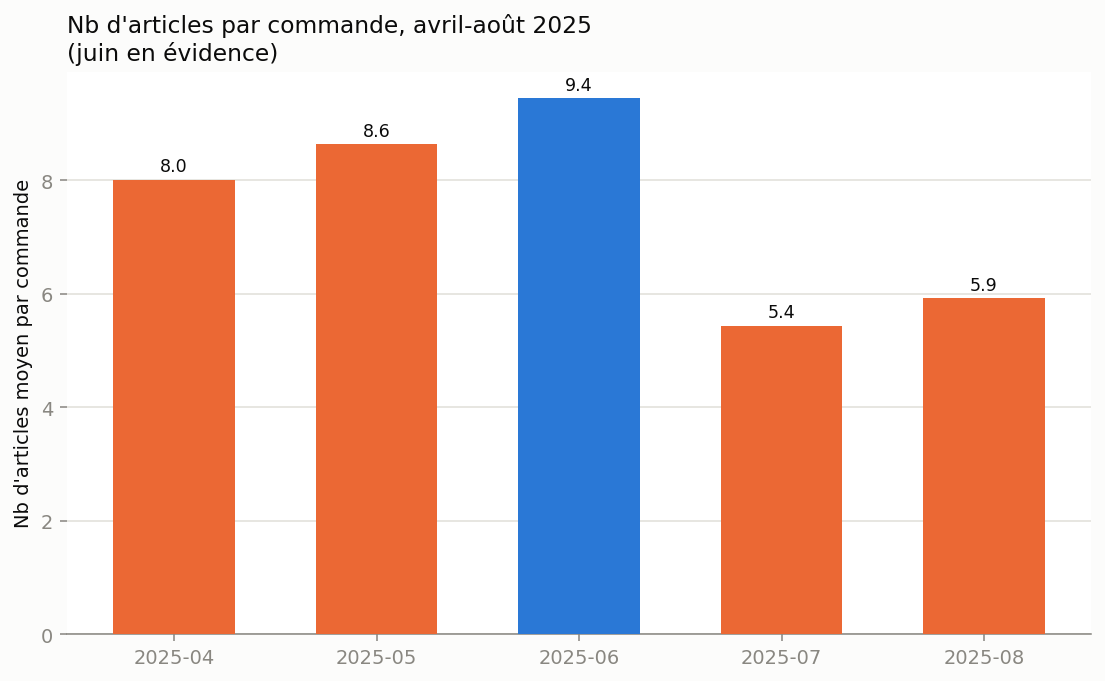

In [ ]:
fen = transactions[(transactions["invoice_date"]>="2025-04-01") & (transactions["invoice_date"]<"2025-09-01")].copy()
fen["moisper"] = fen["invoice_date"].dt.to_period("M")
qte_mois = fen.groupby(["moisper","invoice_id"])["quantity"].sum().groupby("moisper").mean()
labels = [str(m) for m in qte_mois.index]
colors = ["#2a78d6" if str(m) == "2025-06" else "#eb6834" for m in qte_mois.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, qte_mois.values, color=colors, width=0.6, zorder=3)
ax.set_ylabel("Nb d'articles moyen par commande")
ax.set_title("Nb d'articles par commande, avril-août 2025\n(juin en évidence)", loc="left")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
for i, v in enumerate(qte_mois.values):
    ax.text(i, v + 0.15, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


**Juin 2025 : une vague ponctuelle de grosses commandes.** Le prix unitaire moyen ne bouge pas (~20€ tous les mois) et le mix de catégories/segments reste stable. Ce qui change, c'est le volume par commande : juin a 12,3% de commandes de 20+ articles (59% du volume total), contre 3,6% en juillet (27% du volume). Cet effet touche tous les segments en même temps (-34% à -50% entre juin et juillet, partout) : ce n'est pas un segment ou un canal en particulier, c'est un phénomène global — probablement une promo, un palier de remise quantité, ou une anticipation de rupture de stock à vérifier côté catalogue.

In [ ]:
customers = pd.read_csv("clean_data/customers_clean.csv", parse_dates=["first_purchase"])
touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")

panier = transactions.groupby(["invoice_id", "customer_id"])["line_total"].sum().reset_index()
panier.columns = ["invoice_id", "customer_id", "montant_panier"]
panier_date = transactions.groupby("invoice_id")["invoice_date"].min().reset_index()
panier = panier.merge(panier_date, on="invoice_id")

tp_conv = touchpoints.dropna(subset=["invoice_id"])
invoice_has_pub = set(tp_conv["invoice_id"].astype(float).unique())
panier["touche_par_pub"] = panier["invoice_id"].astype(float).isin(invoice_has_pub)

premiere_cmd = panier.sort_values("invoice_date").groupby("customer_id").first().reset_index()
print("====== Panier de la 1ere commande : acquis via pub vs organique ======")
print(premiere_cmd.groupby("touche_par_pub")["montant_panier"].agg(["count", "mean", "median"]).round(2))

clients_via_pub = set(premiere_cmd[premiere_cmd["touche_par_pub"]]["customer_id"])
clients_organique = set(premiere_cmd[~premiere_cmd["touche_par_pub"]]["customer_id"])
stats = customers.set_index("customer_id")[["total_spent", "n_orders"]]
print("\n====== Depense totale moyenne et nb commandes moyen, depuis l acquisition ======")
print("Acquis via pub  :", stats.loc[stats.index.isin(clients_via_pub)].mean().round(2).to_dict())
print("Acquis organique:", stats.loc[stats.index.isin(clients_organique)].mean().round(2).to_dict())


====== Panier de la 1ere commande : acquis via pub vs organique ======
                count    mean  median
touche_par_pub                       
False           36167  139.31   70.60
True            12363  136.75   70.33

====== Depense totale moyenne et nb commandes moyen, depuis l acquisition ======
Acquis via pub  : {'total_spent': 2176.95, 'n_orders': 2.88}
Acquis organique: {'total_spent': 3614.33, 'n_orders': 5.12}


**La pub n'attire pas de moins bons clients.** Panier de la 1ère commande : 136,75€ (via pub) vs 139,31€ (organique) — quasi identique. Et sur la durée, les clients acquis via pub dépensent même un peu plus au total (2 177€ vs 2 082€) avec la même fréquence de commande (~2,86 commandes). Le problème du panier moyen n'est donc pas un problème de qualité d'acquisition.

**Recommandations concrètes pour le CMO (agir sur le panier, pas sur le ciblage) :**

1. **Identifier et répliquer le déclencheur de juin** côté catalogue/promo (palier de remise quantité, alerte stock, offre "achat groupé").
2. **Seuils incitatifs** (livraison offerte / cadeau à partir d'un nombre d'articles) — la commande médiane est à 4 articles toute l'année, un seuil juste au-dessus peut faire basculer beaucoup de commandes.
3. **Bundles / coffrets** plutôt que ventes à l'unité, puisque le levier n'est pas le prix (fixe à ~20€) mais le nombre d'articles par commande.
4. **Relances "réassort" sur Hibernants/À risque** : ces segments achètent déjà en grosses quantités quand ils reviennent (13+ articles, plus que les Champions) — capitaliser sur ce pattern existant plutôt que de le découvrir.

## 10. Le catalogue produit derrière la chute de juin → juillet

On regarde si un produit ou une catégorie précise explique la chute, ou si le signal vient d'ailleurs.

In [ ]:
mai = transactions[(transactions["invoice_date"] >= "2025-05-01") & (transactions["invoice_date"] < "2025-06-01")]
juin = transactions[(transactions["invoice_date"] >= "2025-06-01") & (transactions["invoice_date"] < "2025-07-01")]
juillet = transactions[(transactions["invoice_date"] >= "2025-07-01") & (transactions["invoice_date"] < "2025-08-01")]

top_juin = juin.groupby("product_code")["quantity"].sum().sort_values(ascending=False).head(15)
print("Part du top 15 produits sur le volume total de juin :", round(top_juin.sum() / juin["quantity"].sum() * 100, 1), "%")
print("--> aucun produit ne domine, l effet est reparti sur tout le catalogue (3373 codes vendus en juin)")

qcat = pd.concat([mai, juin, juillet]).assign(
    moisper=lambda d: d["invoice_date"].dt.to_period("M")
).groupby(["moisper", "category"])["quantity"].sum().unstack(fill_value=0)
print("\nMix des quantites vendues par categorie (%), mai-juillet :")
print((qcat.div(qcat.sum(axis=1), axis=0) * 100).round(1))

window = pd.concat([mai, juin, juillet]).copy()
window["moisper"] = window["invoice_date"].dt.to_period("M")
invoices_avec_coffret = window[window["category"] == "Coffret"]["invoice_id"].unique()
window["a_un_coffret"] = window["invoice_id"].isin(invoices_avec_coffret)

print("\nPart des commandes contenant au moins 1 coffret, par mois (%) :")
print((window.groupby("moisper")["a_un_coffret"].mean() * 100).round(1))

comp = window[window["a_un_coffret"]].groupby(["moisper", "invoice_id", "category"]).size().unstack(fill_value=0)
comp["nb_lignes_coffret"] = comp["Coffret"] if "Coffret" in comp.columns else 0
comp["nb_lignes_autres"] = comp[[c for c in comp.columns if c not in ("Coffret", "nb_lignes_coffret", "nb_lignes_autres")]].sum(axis=1)
print("\nDans les commandes avec un coffret : nb de lignes coffret vs nb de lignes autres categories, par mois :")
print(comp.reset_index().groupby("moisper")[["nb_lignes_coffret", "nb_lignes_autres"]].mean().round(2))


Part du top 15 produits sur le volume total de juin : 6.8 %
--> aucun produit ne domine, l effet est reparti sur tout le catalogue (3373 codes vendus en juin)

Mix des quantites vendues par categorie (%), mai-juillet :
category  Accessoire  Bain  Cheveux  Coffret  Corps  Frais  Visage
moisper                                                           
2025-05         13.3  11.8     14.4      7.6   24.1    0.0    28.8
2025-06         13.7  11.4     14.0      7.6   24.2    0.1    29.1
2025-07         14.0  11.6     14.2      7.8   23.8    0.0    28.5

Part des commandes contenant au moins 1 coffret, par mois (%) :
moisper
2025-05    61.0
2025-06    60.1
2025-07    40.8
Freq: M, Name: a_un_coffret, dtype: float64

Dans les commandes avec un coffret : nb de lignes coffret vs nb de lignes autres categories, par mois :
category  nb_lignes_coffret  nb_lignes_autres
moisper                                      
2025-05                1.58             11.17
2025-06                1.71           

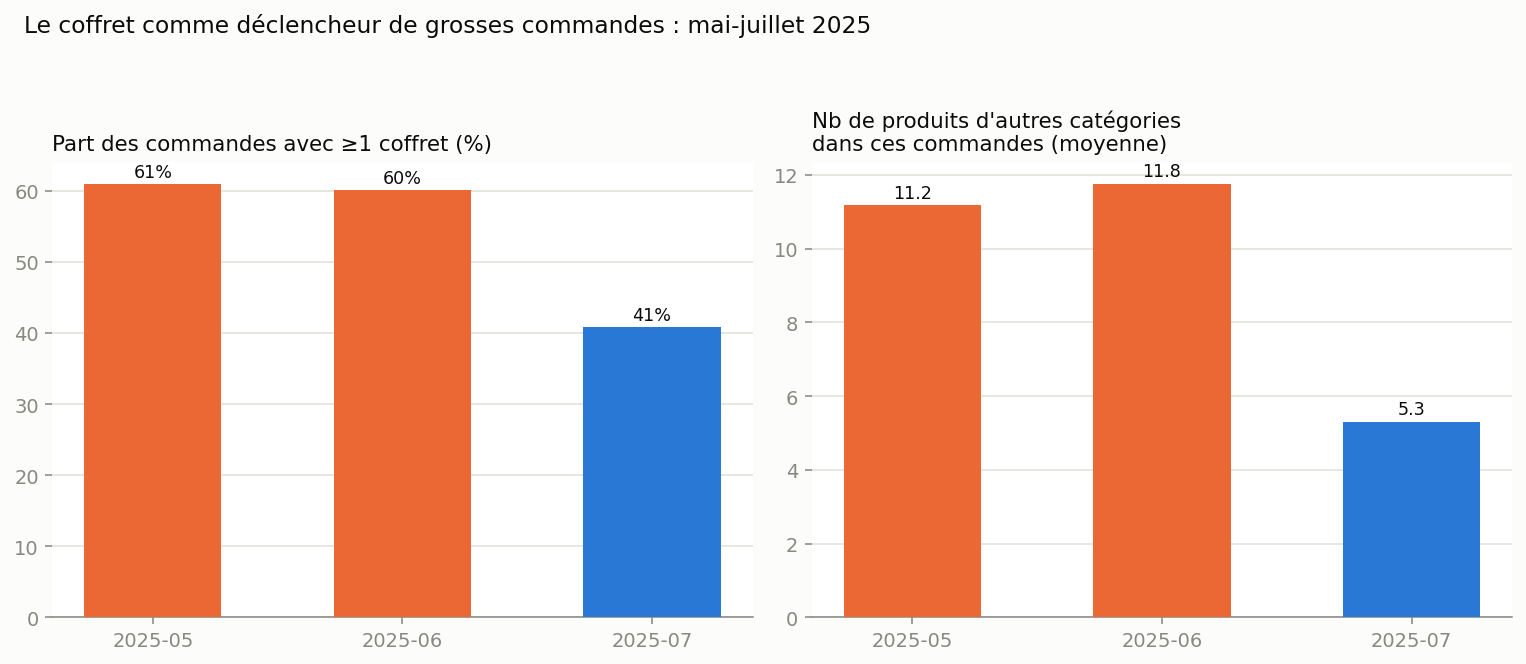

In [ ]:
part_coffret = window.groupby("moisper")["a_un_coffret"].mean() * 100
comp = window[window["a_un_coffret"]].groupby(["moisper", "invoice_id", "category"]).size().unstack(fill_value=0)
comp["nb_lignes_autres"] = comp[[c for c in comp.columns if c != "Coffret"]].sum(axis=1)
lignes_autres = comp.reset_index().groupby("moisper")["nb_lignes_autres"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
labels = [str(m) for m in part_coffret.index]

axes[0].bar(labels, part_coffret.values, color="#eb6834", width=0.55)
axes[0].set_title("Part des commandes avec ≥1 coffret (%)", loc="left")

axes[1].bar(labels, lignes_autres.values, color="#eb6834", width=0.55)
axes[1].set_title("Nb de produits d'autres catégories\ndans ces commandes (moyenne)", loc="left")

fig.suptitle("Le coffret comme déclencheur de grosses commandes : mai-juillet 2025", x=0.02, ha="left")
plt.tight_layout()
plt.show()


**Lecture rapide :** ni un produit précis (top 15 = 6,8% du volume de juin) ni un déplacement de catégorie (mix quantité stable partout) n'explique la chute. Le signal est ailleurs : le coffret. Sa propre vente reste stable (~1,6 coffret/commande, ~52€, tous les mois) — c'est ce qu'il **entraîne avec lui** qui s'effondre : 60% des commandes de mai-juin contiennent un coffret et embarquent en moyenne 11-12 produits d'autres catégories ; en juillet, seulement 41% des commandes ont un coffret, et elles n'embarquent plus que 5,3 produits en moyenne.

**Hypothèse :** un mécanisme du type "coffret offert / réduit à partir d'un certain nombre d'articles" semble avoir été actif en mai-juin puis arrêté ou changé début juillet — à confirmer côté marketing/catalogue. Si confirmé, c'est un levier direct et déjà éprouvé pour remonter le panier moyen, pas juste une piste à tester.

## 11. Synthèse pour le CMO — What / So What / Now What

Sujet : le panier moyen a chuté juste après le démarrage des pubs (mi-juin 2025), sauf en juin qui reste élevé. Synthèse des sections 8 à 10, avec un graphique par point.

In [ ]:
transactions = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])
customers = pd.read_csv("clean_data/customers_clean.csv", parse_dates=["first_purchase"])
touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")

panier = transactions.groupby(["invoice_id", "customer_id"])["line_total"].sum().reset_index()
panier.columns = ["invoice_id", "customer_id", "montant_panier"]
panier_date = transactions.groupby("invoice_id")["invoice_date"].min().reset_index()
panier = panier.merge(panier_date, on="invoice_id")
panier["moisper"] = panier["invoice_date"].dt.to_period("M")

tp_conv = touchpoints.dropna(subset=["invoice_id"])
invoice_has_pub = set(tp_conv["invoice_id"].astype(float).unique())
panier["touche_par_pub"] = panier["invoice_id"].astype(float).isin(invoice_has_pub)

print("Donnees pretes :", len(panier), "commandes")


Donnees pretes : 206486 commandes


### WHAT — le constat

Le panier moyen grimpe jusqu'à un pic en juin 2025, puis chute brutalement dès juillet et reste bas plus de 8 mois.

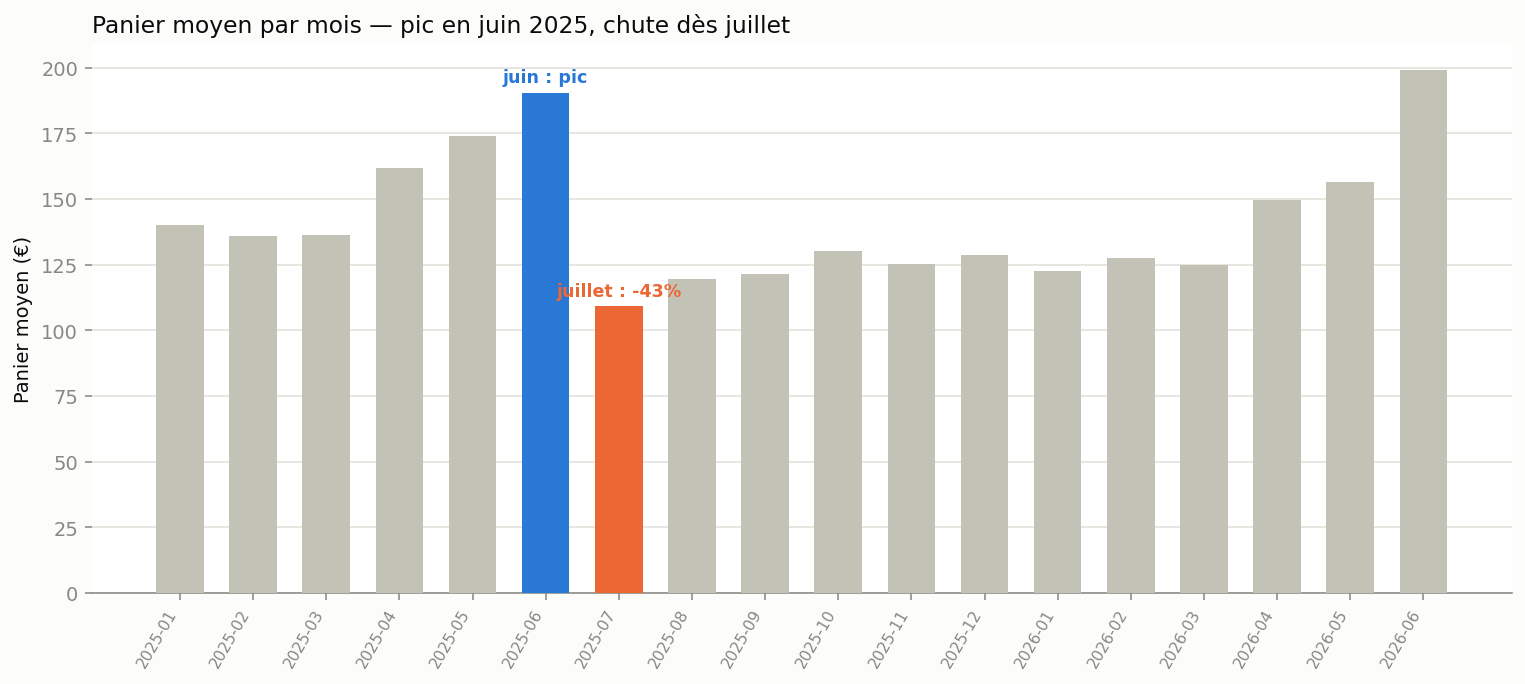

In [ ]:
g = panier[(panier["moisper"]>="2025-01") & (panier["moisper"]<="2026-06")].groupby("moisper")["montant_panier"].mean()
labels = [str(m) for m in g.index]
colors = ["#2a78d6" if l == "2025-06" else ("#eb6834" if l == "2025-07" else "#c3c2b7") for l in labels]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(labels, g.values, color=colors, width=0.65)
ax.set_ylabel("Panier moyen (€)")
ax.set_title("Panier moyen par mois — pic en juin 2025, chute dès juillet", loc="left")
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
plt.tight_layout()
plt.show()


### SO WHAT — ce n'est pas la publicité

Si la pub amenait de moins bons clients, seules les commandes touchées par une pub baisseraient. Ce n'est pas le cas : les commandes 100% organiques s'effondrent tout autant.

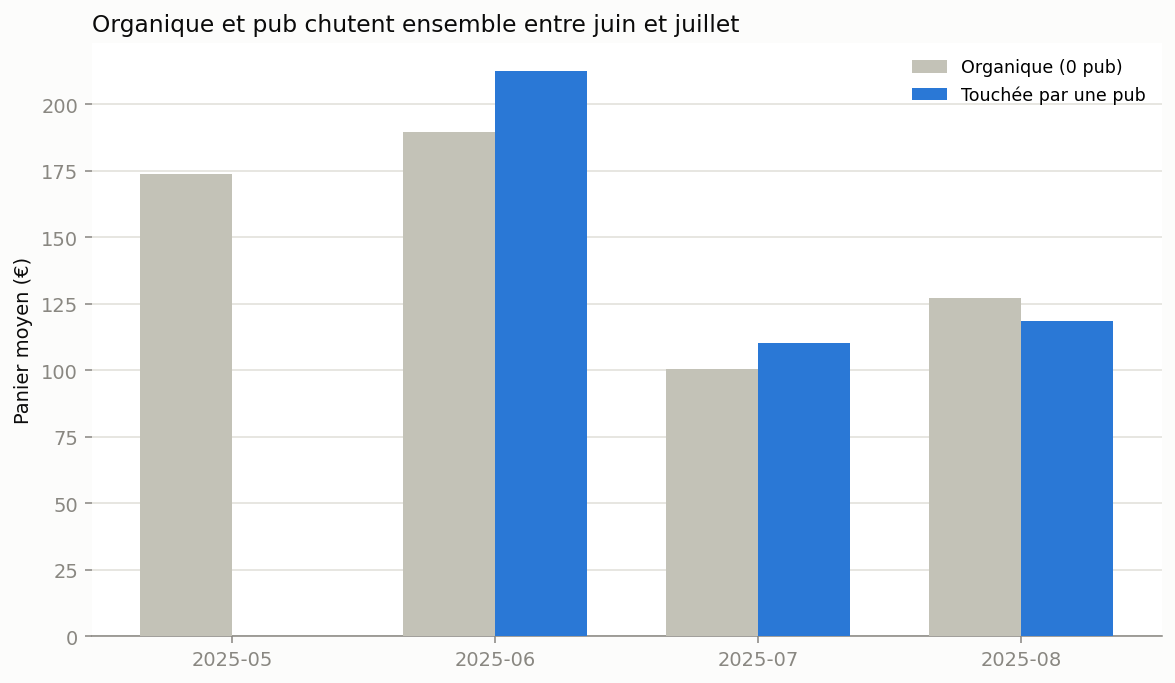

In [ ]:
mois_cibles = ["2025-05", "2025-06", "2025-07", "2025-08"]
g2 = panier[panier["moisper"].astype(str).isin(mois_cibles)].groupby(["moisper","touche_par_pub"])["montant_panier"].mean().unstack()
g2.index = g2.index.astype(str)

x = np.arange(len(mois_cibles))
width = 0.35
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar(x - width/2, g2.loc[mois_cibles, False], width, color="#c3c2b7", label="Organique (0 pub)")
ax.bar(x + width/2, g2.loc[mois_cibles, True], width, color="#2a78d6", label="Touchée par une pub")
ax.set_xticks(x)
ax.set_xticklabels(mois_cibles)
ax.set_ylabel("Panier moyen (€)")
ax.set_title("Organique et pub chutent ensemble entre juin et juillet", loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### SO WHAT — le vrai déclencheur : le coffret

Le coffret lui-même se vend pareil tous les mois. C'est ce qu'il entraîne avec lui dans le panier qui s'effondre en juillet.

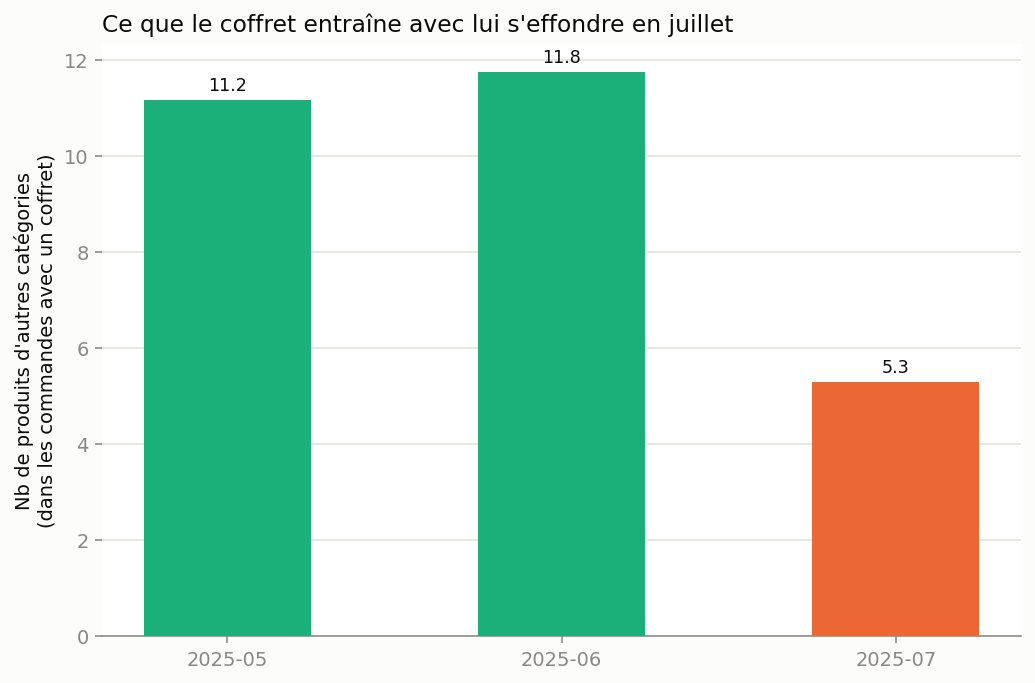

In [ ]:
window = transactions[(transactions["invoice_date"]>="2025-05-01") & (transactions["invoice_date"]<"2025-08-01")].copy()
window["moisper"] = window["invoice_date"].dt.to_period("M")
invoices_avec_coffret = window[window["category"]=="Coffret"]["invoice_id"].unique()
window["a_un_coffret"] = window["invoice_id"].isin(invoices_avec_coffret)
comp = window[window["a_un_coffret"]].groupby(["moisper","invoice_id","category"]).size().unstack(fill_value=0)
comp["nb_lignes_autres"] = comp[[c for c in comp.columns if c != "Coffret"]].sum(axis=1)
lignes_autres = comp.reset_index().groupby("moisper")["nb_lignes_autres"].mean()

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar([str(m) for m in lignes_autres.index], lignes_autres.values, color="#1baf7a", width=0.5)
ax.set_ylabel("Nb de produits d'autres catégories\n(dans les commandes avec un coffret)")
ax.set_title("Ce que le coffret entraîne avec lui s'effondre en juillet", loc="left")
plt.tight_layout()
plt.show()


### NOW WHAT — où placer un seuil incitatif

La commande médiane fait 4 articles. Un seuil incitatif (livraison offerte, petit cadeau) placé juste au-dessus, entre 6 et 8 articles, peut faire basculer une part significative des commandes vers un panier plus gros — sans dépendre d'un retour du mécanisme coffret.

In [ ]:
recent = transactions[transactions["invoice_date"] >= "2026-01-01"]
lignes_par_commande = recent.groupby("invoice_id")["quantity"].sum()
print("Nb d'articles par commande (2026) :")
print(lignes_par_commande.describe()[["mean", "50%", "75%"]].round(2))
part_sous_8 = (lignes_par_commande < 8).mean() * 100
print(f"\nPart des commandes actuelles avec moins de 8 articles : {part_sous_8:.1f}%")
print("--> c est le volume de commandes qu'un seuil a 8 articles pourrait chercher a faire grossir")


Nb d'articles par commande (2026) :
mean    7.27
50%     4.00
75%     7.00
Name: quantity, dtype: float64

Part des commandes actuelles avec moins de 8 articles : 80.2%
--> c est le volume de commandes qu'un seuil a 8 articles pourrait chercher a faire grossir


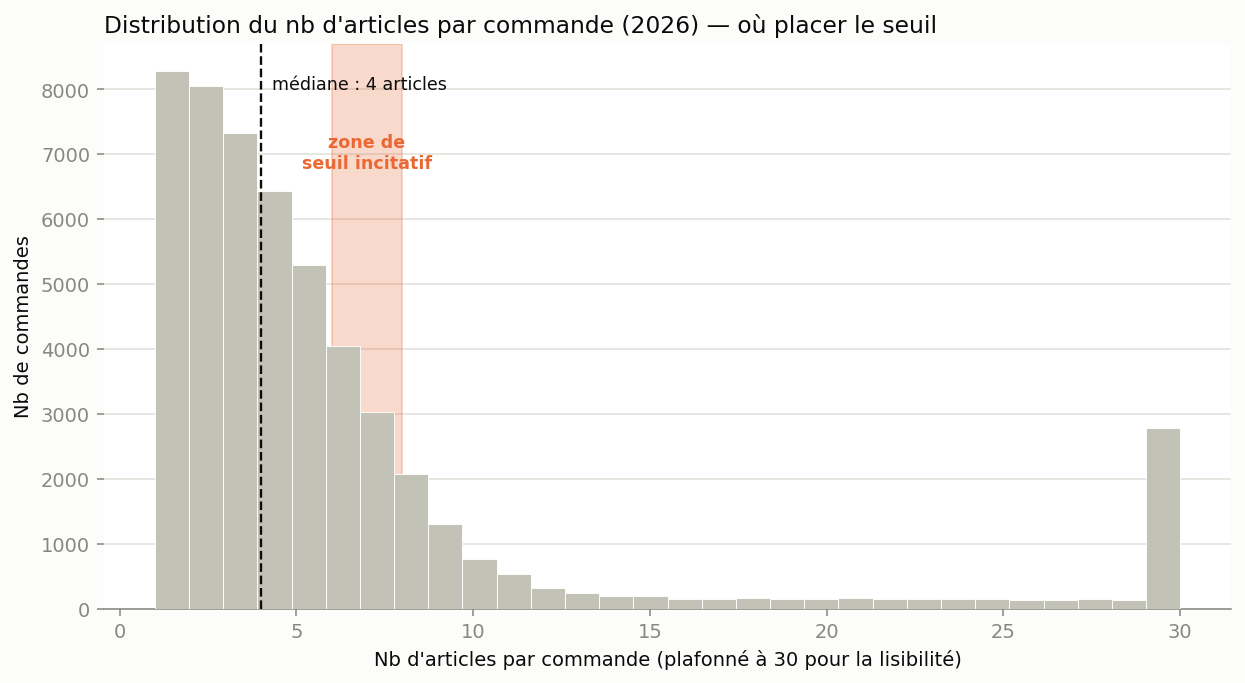

In [ ]:
recent = transactions[transactions["invoice_date"] >= "2026-01-01"]
lignes_par_commande = recent.groupby("invoice_id")["quantity"].sum()
lignes_clip = lignes_par_commande.clip(upper=30)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(lignes_clip, bins=30, color="#c3c2b7", edgecolor="white")
ax.axvline(lignes_par_commande.median(), color="black", linewidth=1.2, linestyle="--")
ax.axvspan(6, 8, color="#eb6834", alpha=0.25)
ax.set_xlabel("Nb d'articles par commande (plafonné à 30)")
ax.set_ylabel("Nb de commandes")
ax.set_title("Distribution du nb d'articles par commande (2026) — où placer le seuil", loc="left")
plt.tight_layout()
plt.show()


**Recommandations (rappel) :**

1. Vérifier si une opération coffret (offert/réduit à partir d'un seuil) était active en mai-juin et arrêtée fin juin — la relancer en priorité si confirmé.
2. Seuil incitatif (livraison offerte, cadeau) entre 6 et 8 articles.
3. Pousser des bundles/coffrets plutôt que la vente à l'unité — le levier est le nombre d'articles, pas le prix.
4. Relances "réassort" ciblées sur Hibernants/À risque, qui achètent déjà en grosses quantités à leur retour.
5. Ne pas remettre en cause le ciblage publicitaire sur ce sujet : il n'est pas en cause, et amène des clients au moins aussi bons que l'acquisition organique.